# 05d — Prima e dopo il riallineamento a lunghezza del riferimento

I quattro notebook di confronto **non generano nulla**: leggono i file di metriche salvati in
`results/metrics/` e costruiscono tabelle e grafici; si possono eseguire in qualunque momento,
su qualunque sottoinsieme di risultati disponibile (i metodi mancanti vengono saltati). Gli
helper comuni — elenco dei 18 slug, palette, caricamento con intersezione dei `row_id`, tabella
delle medie, grafici a barre — stanno in `summ_utils.py` (sezione *Confronto fra metodi*).

| notebook | ambito | contenuto |
|---|---|---|
| **05a** | `full` | TextRank vs LexRank sull'intero dataset (56.101 esempi) |
| **05b** | `test` | tutti i 18 metodi sulla split test: **il confronto principale del benchmark** |
| **05c** | `test_budgetref` | gli stessi 18 a lunghezza del riferimento, stessa presentazione di 05b |
| **05d** | `test` → `test_budgetref` | prima/dopo il riallineamento: metriche, dispersione, G-Eval |

## Il confronto *length-matched*

Il notebook 05b confronta i metodi così come generano; il notebook 18 mostra che così facendo
si confrontano riassunti di lunghezza molto diversa — dentro un singolo cluster il più lungo dei
18 è in mediana **8,5 volte** il più corto — e che la lunghezza spiega da sola gran parte del
ROUGE *recall* (r ≈ 0,89 fra metodi). Il notebook 05c rifà il confronto sull'ambito
`test_budgetref` (issue #16), in cui ogni metodo ha, per ogni cluster, lo **stesso budget di
parole: la lunghezza del riassunto di riferimento**. Questo notebook mette i due ambiti uno
accanto all'altro: come è stato applicato il riallineamento, le sue avvertenze e come leggere i
numeri sono nel notebook 05c.

**Risultato (corse 2026-09-13/17, 5.527 cluster comuni ai 18 metodi).** I **15 slug rigenerati**
cadono in banda nel **71–100%** dei cluster (gli 11 estrattivi 93–99%, `gpt5mini` 100%, `gemma`
99%, `qwen` 79%, `mistral` 71%), con lunghezza mediana pari al riferimento (~215 parole).

Il rapporto fra il riassunto più lungo e il più corto dentro lo stesso cluster passa da 8,5× a
4,7× contando tutti e 18 i metodi — ma quel 4,7 è quasi interamente `bart`, che a 0,26× il
riferimento è il minimo in quasi ogni cluster mentre il tetto tiene il massimo a 1,25×
(1,25/0,26 ≈ 4,8). Tolto lui il quadro cambia:

| insieme di metodi | prima | dopo |
|---|---:|---:|
| tutti e 18 | 8,5× | 4,7× |
| senza `bart` (17) | 3,8× | **1,6×** |
| i soli 15 rigenerati | 3,7× | **1,4×** |

Fra i metodi effettivamente riportati a lunghezza pari la dispersione dentro il cluster è quindi
quasi annullata: il numero sui 18 sottostima il contenimento.

A parità di lunghezza la graduatoria si riassesta, in tre modi:

- **`lda` perde tutto**: recall 0,499 → 0,348 e **ultimo posto** fra gli estrattivi in F1
  (0,351 → 0,338). Il vantaggio era interamente di lunghezza, come sospettato nella issue #14.
- **Le baseline `firstk_*` salgono dal 9°–10° al 5°–6° posto** (F1 0,368), sopra `lda`, `lsa`,
  `sbert_*`, `textrank` e `lexrank`: a parità di parole, prendere le prime frasi di ogni articolo
  regge il confronto con metodi di selezione molto più elaborati. È il risultato più scomodo
  dell'esercizio e anche il più interessante. `centroid_mmr` resta comunque il miglior estrattivo
  (0,378), seguito da `lsa_steinberger` (0,369).
- **I metodi corti guadagnano**, perché la rigenerazione a budget dà loro lo spazio che prima non usavano:
  `qwen` 0,344 → 0,351, `mistral` 0,354 → 0,365. Il confondente della lunghezza tagliava in
  **entrambe** le direzioni, non solo a favore dei lunghi.
- `primera` (0,446) e `pegasus` (0,424), già a lunghezza di riferimento e non rigenerati, restano
  primo e secondo del benchmark: il loro vantaggio **non** era di lunghezza.

In [1]:
# --- Configurazione ---------------------------------------------------------
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)
su.stile_grafici()

# Palette e costanti condivise dai notebook 05a-05d (definite una volta in summ_utils)
COLORI = su.COLORI_METODI
INK, INK2, MUTED, GRID, SURFACE = su.INK, su.INK2, su.MUTED, su.GRID, su.SURFACE
METODI = su.METODI_BENCHMARK

## Tabella prima/dopo per metodo

`Δ` = dopo − prima; «in banda %» = quota di cluster con lunghezza entro [0,8, 1,25] × riferimento (dal notebook 18 sull'ambito `test_budgetref`).

In [2]:
test_dati = su.carica_scope(P['metrics_dir'], 'test', METODI)
budget_dati = su.carica_scope(P['metrics_dir'], 'test_budgetref', METODI)

def rigenerato(metodo):
    return (budget_dati[metodo]['agg'].get('config', {}).get('ambito_budget', {})
            .get('rigenerato_a_budget'))

if budget_dati and test_dati:
    comuni = [m for m in METODI if m in budget_dati and m in test_dati]
    prima, dopo = su.tabella_medie({m: test_dati[m] for m in comuni}), su.tabella_medie(budget_dati)
    colonne = [c for c in ['parole_generate', 'rouge1_f1', 'rouge2_f1', 'rougeL_f1',
                           'bleu', 'meteor', 'bertscore_f1', 'geval_media']
               if c in prima.columns and c in dopo.columns]
    # recall e precision ROUGE-1 non sono in METRICHE_CHIAVE: qui sono il punto, si aggiungono
    for nome, d in (('prima', test_dati), ('dopo', budget_dati)):
        for m in comuni:
            df = d[m]['df']
            (prima if nome == 'prima' else dopo).loc[m, 'rouge1_r'] = df['rouge1_r'].mean()
            (prima if nome == 'prima' else dopo).loc[m, 'rouge1_p'] = df['rouge1_p'].mean()
    colonne = ['parole_generate', 'rouge1_r', 'rouge1_p'] + [c for c in colonne if c != 'parole_generate']

    # quota di righe in banda [0,8, 1,25] x riferimento: calcolata dal notebook 18 sull'ambito
    # test_budgetref (results/metrics/analisi_lunghezze_test_budgetref.json), se disponibile
    in_banda = {}
    analisi_path = P['metrics_dir'] / 'analisi_lunghezze_test_budgetref.json'
    if analisi_path.exists():
        with open(analisi_path, encoding='utf-8') as f:
            in_banda = {m: v['pct_in_banda'] for m, v in json.load(f)['per_metodo'].items()}

    confronto = pd.DataFrame(index=comuni)
    confronto['rigenerato'] = [bool(rigenerato(m)) for m in comuni]
    if in_banda:
        confronto['in banda %'] = [in_banda.get(m) for m in comuni]
    for c in colonne:
        confronto[f'{c} prima'] = prima.loc[comuni, c]
        confronto[f'{c} dopo'] = dopo.loc[comuni, c]
        confronto[f'Δ {c}'] = dopo.loc[comuni, c] - prima.loc[comuni, c]
    confronto['n_esempi'] = dopo.loc[comuni, 'n_esempi'].astype(int)
    print(f"Ambito test_budgetref: {len(comuni)} metodi, "
          f"{int(confronto['rigenerato'].sum())} rigenerati a budget, "
          f"{len(comuni) - int(confronto['rigenerato'].sum())} col solo tetto.")
    with pd.option_context('display.max_columns', None, 'display.width', 250):
        display(confronto.sort_values('rouge1_f1 dopo', ascending=False).round(3))
else:
    print("Ambito 'test_budgetref' non disponibile: eseguire "
          "scripts/run_benchmark_test.py --scope test_budgetref e poi scripts/applica_budget.py.")

test: confronto su 5437 esempi comuni a 18 metodi con copertura piena


test_budgetref: confronto su 5527 esempi comuni a 18 metodi con copertura piena
Ambito test_budgetref: 18 metodi, 15 rigenerati a budget, 3 col solo tetto.


,rigenerato,in banda %,parole_generate prima,parole_generate dopo,Δ parole_generate,rouge1_r prima,rouge1_r dopo,Δ rouge1_r,rouge1_p prima,rouge1_p dopo,Δ rouge1_p,rouge1_f1 prima,rouge1_f1 dopo,Δ rouge1_f1,rouge2_f1 prima,rouge2_f1 dopo,Δ rouge2_f1,rougeL_f1 prima,rougeL_f1 dopo,Δ rougeL_f1,bleu prima,bleu dopo,Δ bleu,meteor prima,meteor dopo,Δ meteor,bertscore_f1 prima,bertscore_f1 dopo,Δ bertscore_f1,geval_media prima,geval_media dopo,Δ geval_media,n_esempi
primera,False,65.9,210.400,201.059,-9.341,0.441,0.433,-0.008,0.465,0.473,0.007,0.444,0.446,0.002,0.198,0.198,0.001,0.248,0.250,0.002,0.147,0.150,0.003,0.474,0.469,-0.006,0.874,0.875,0.001,4.285,4.224,-0.061,5527
pegasus,False,52.1,178.065,175.135,-2.930,0.390,0.387,-0.002,0.480,0.484,0.004,0.423,0.425,0.001,0.180,0.181,0.001,0.240,0.241,0.001,0.132,0.133,0.001,0.068,0.072,0.004,0.871,0.871,0.000,4.045,4.031,-0.014,5527
centroid_mmr,True,97.5,361.281,214.847,-146.434,0.465,0.365,-0.100,0.340,0.396,0.056,0.383,0.378,-0.005,0.144,0.137,-0.008,0.189,0.197,0.009,0.097,0.116,0.019,0.500,0.413,-0.088,0.842,0.847,0.005,2.743,2.795,0.052,5527
lsa_steinberger,True,98.5,257.248,214.848,-42.400,0.419,0.366,-0.053,0.357,0.376,0.019,0.375,0.370,-0.006,0.138,0.132,-0.005,0.188,0.191,0.003,0.103,0.117,0.014,0.452,0.404,-0.048,0.842,0.843,0.001,2.705,2.613,-0.092,5527
firstk_psr,True,98.0,216.348,214.364,-1.984,0.347,0.354,0.007,0.386,0.388,0.002,0.354,0.368,0.014,0.121,0.129,0.008,0.180,0.190,0.010,0.082,0.104,0.022,0.389,0.407,0.018,0.840,0.844,0.004,2.860,2.856,-0.005,5527
firstk_nltk,True,98.1,218.500,214.430,-4.071,0.348,0.353,0.004,0.387,0.389,0.001,0.356,0.368,0.012,0.123,0.130,0.007,0.181,0.190,0.009,0.083,0.105,0.021,0.391,0.406,0.015,0.842,0.847,0.004,3.375,3.381,0.006,5527
mistral,True,71.3,161.209,232.234,71.025,0.325,0.368,0.043,0.410,0.370,-0.040,0.354,0.366,0.012,0.111,0.122,0.011,0.190,0.198,0.008,0.067,0.084,0.017,0.361,0.431,0.070,0.860,0.861,0.001,4.723,4.595,-0.128,5527
centroid_mmr_bert,True,97.5,361.133,214.735,-146.398,0.460,0.357,-0.104,0.325,0.375,0.050,0.372,0.364,-0.008,0.138,0.127,-0.011,0.186,0.192,0.006,0.094,0.111,0.017,0.498,0.413,-0.085,0.841,0.846,0.005,2.744,2.791,0.048,5527
textrank,True,97.6,367.668,214.811,-152.858,0.448,0.344,-0.105,0.330,0.381,0.052,0.369,0.359,-0.010,0.135,0.124,-0.011,0.176,0.185,0.009,0.088,0.105,0.017,0.488,0.403,-0.085,0.840,0.843,0.003,2.307,2.574,0.266,5527
sbert_kmeans,True,98.1,263.500,214.424,-49.075,0.404,0.358,-0.046,0.337,0.363,0.026,0.359,0.359,0.000,0.126,0.122,-0.003,0.183,0.188,0.004,0.096,0.108,0.012,0.443,0.408,-0.035,0.840,0.844,0.004,2.642,2.683,0.041,5527


## Grafici prima/dopo

ROUGE-1 recall e F1, G-Eval, parole per riassunto; poi la correlazione fra lunghezza media e recall fra metodi, prima e dopo — è quella che deve sparire.

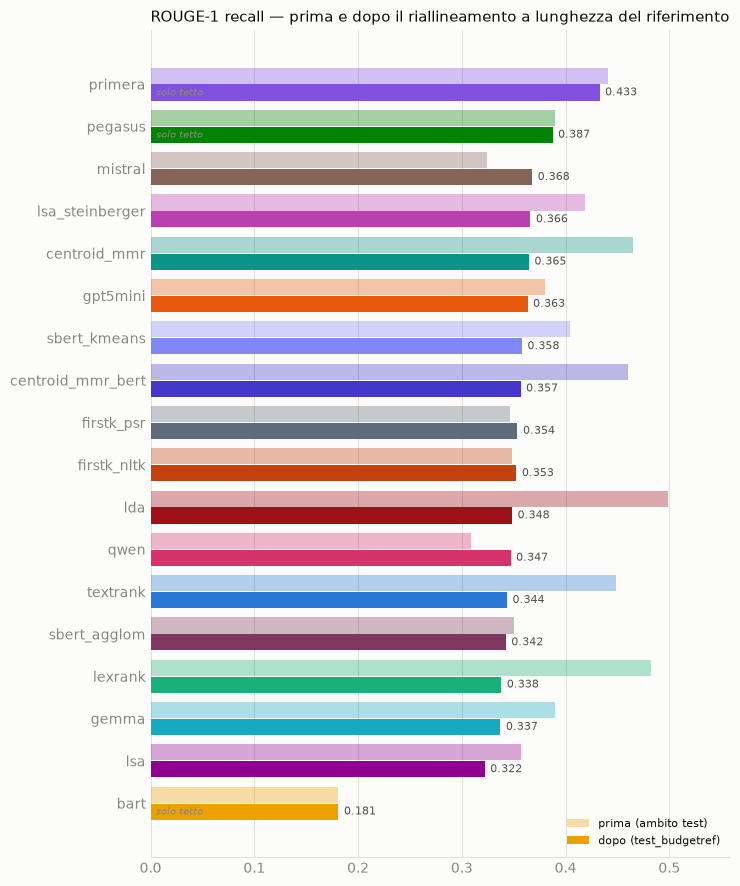

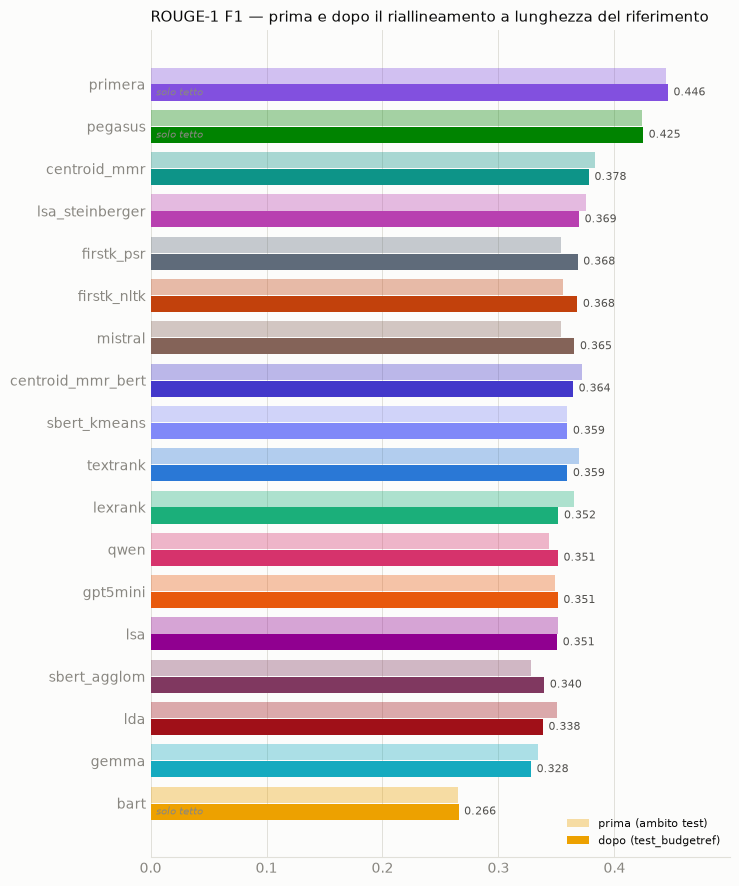

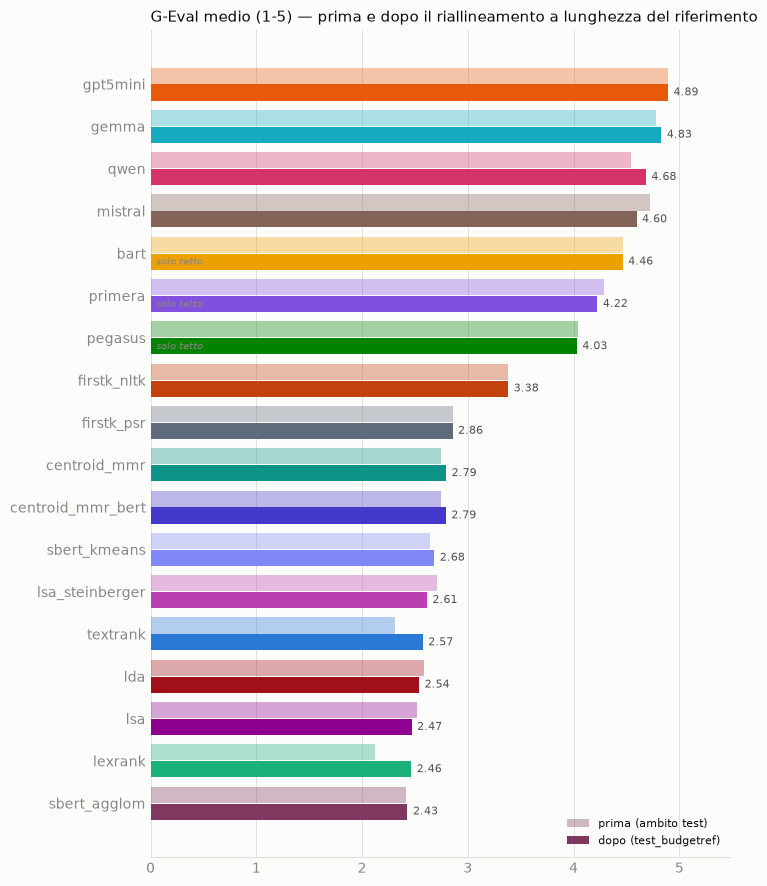

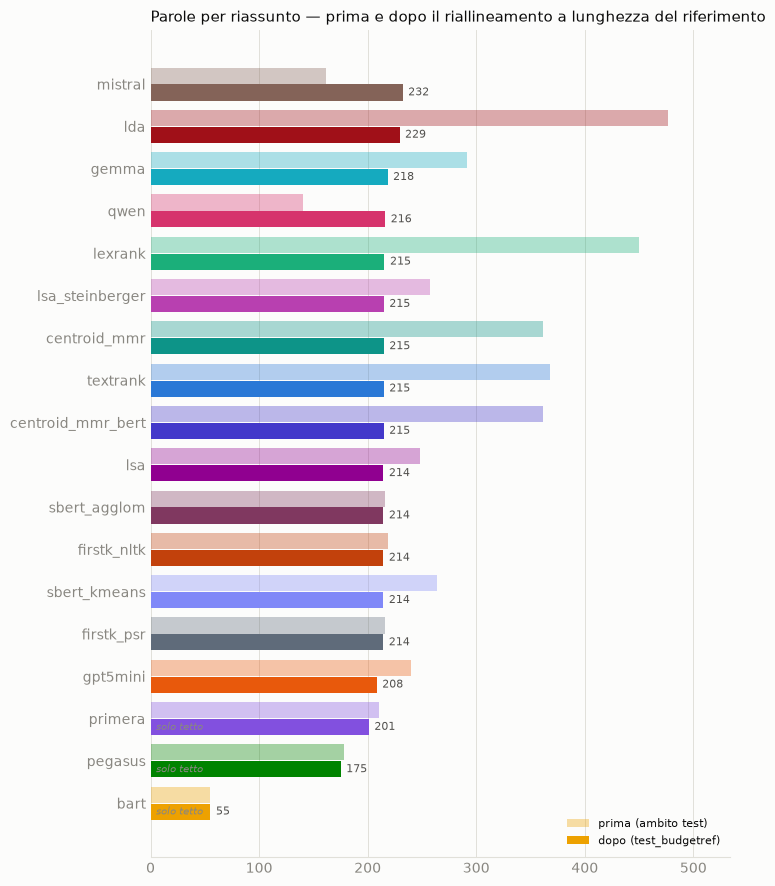

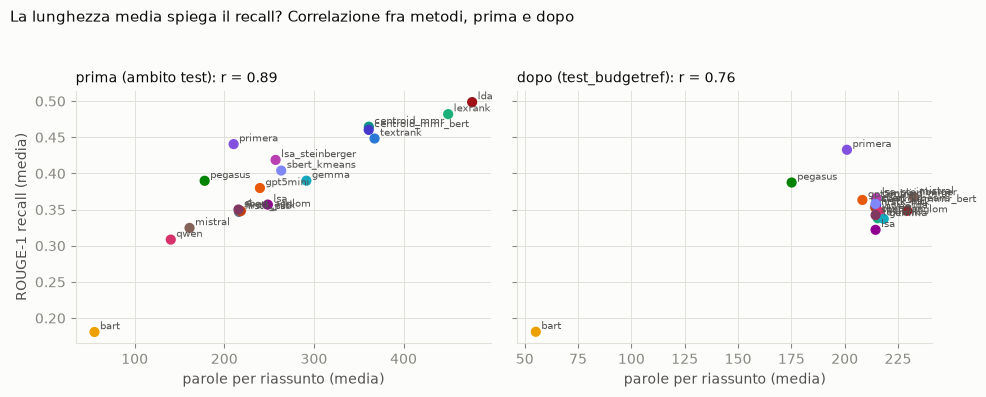

In [3]:
if budget_dati and test_dati:
    def barre_prima_dopo(metrica, etichetta, fmt='{:.3f}'):
        """Barre appaiate prima/dopo per metodo, ordinate per il valore «dopo»."""
        metodi = sorted(comuni, key=lambda m: dopo.loc[m, metrica])
        y = np.arange(len(metodi))
        fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(metodi) + 1.4), facecolor=SURFACE)
        ax.set_facecolor(SURFACE)
        ax.barh(y + 0.2, [prima.loc[m, metrica] for m in metodi], height=0.38,
                color=[COLORI[m] for m in metodi], alpha=0.35, zorder=2, label='prima (ambito test)')
        ax.barh(y - 0.2, [dopo.loc[m, metrica] for m in metodi], height=0.38,
                color=[COLORI[m] for m in metodi], zorder=3, label='dopo (test_budgetref)')
        for yi, m in zip(y, metodi):
            ax.annotate(fmt.format(dopo.loc[m, metrica]), (dopo.loc[m, metrica], yi - 0.2),
                        xytext=(4, 0), textcoords='offset points', va='center', fontsize=8, color=INK2)
            if not rigenerato(m):
                ax.annotate('solo tetto', (0, yi - 0.2), xytext=(4, 0), textcoords='offset points',
                            va='center', fontsize=7, color=MUTED, style='italic')
        ax.set_yticks(y, metodi)
        ax.set_title(f'{etichetta} — prima e dopo il riallineamento a lunghezza del riferimento',
                     color=INK, loc='left', fontsize=11)
        ax.grid(axis='x', color=GRID, linewidth=0.7, zorder=0)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(length=0)
        ax.margins(x=0.12)
        ax.legend(frameon=False, fontsize=8, loc='lower right')
        plt.tight_layout()
        plt.show()

    barre_prima_dopo('rouge1_r', 'ROUGE-1 recall')
    barre_prima_dopo('rouge1_f1', 'ROUGE-1 F1')
    if 'geval_media' in dopo.columns and dopo['geval_media'].notna().all():
        barre_prima_dopo('geval_media', 'G-Eval medio (1-5)', fmt='{:.2f}')
    barre_prima_dopo('parole_generate', 'Parole per riassunto', fmt='{:.0f}')

    # La lunghezza spiega ancora il recall? Correlazione fra metodi, prima vs dopo
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=SURFACE, sharey=True)
    for ax, (nome, tab) in zip(axes, (('prima (ambito test)', prima), ('dopo (test_budgetref)', dopo))):
        ax.set_facecolor(SURFACE)
        x = tab.loc[comuni, 'parole_generate'].astype(float)
        yv = tab.loc[comuni, 'rouge1_r'].astype(float)
        ax.scatter(x, yv, c=[COLORI[m] for m in comuni], s=40, zorder=3)
        for m in comuni:
            ax.annotate(m, (x[m], yv[m]), xytext=(4, 2), textcoords='offset points', fontsize=7, color=INK2)
        r = np.corrcoef(x, yv)[0, 1]
        ax.set_title(f'{nome}: r = {r:.2f}', color=INK, loc='left', fontsize=10)
        ax.set_xlabel('parole per riassunto (media)')
        ax.grid(color=GRID, linewidth=0.7, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)
    axes[0].set_ylabel('ROUGE-1 recall (media)')
    fig.suptitle('La lunghezza media spiega il recall? Correlazione fra metodi, prima e dopo',
                 color=INK, x=0.01, ha='left', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

### Il G-Eval a lunghezza pari: la lunghezza non era il suo confondente

Il G-Eval dell'ambito `test_budgetref` viene dallo stesso giudice `gpt-5.4-mini` dei numeri
pubblicati (validato nel notebook 19), sui testi **post-troncamento** — esattamente quelli su cui
sono calcolate le altre metriche di questa vista — con i giudizi dei testi rimasti identici
riusati dalla cache `test` (bart 94 %, pegasus 84 %, primera 74 %). Corsa del 2026-09-18/19,
100.712 giudizi, 99.040 riusciti.

Il risultato è l'opposto di quello del ROUGE. Dove il riallineamento ha ribaltato il *recall*
(`lda` −0,15, `centroid_mmr` −0,10) e rimescolato la graduatoria ROUGE, **le prime undici
posizioni del G-Eval restano identiche** e il massimo spostamento è di 0,34 punti su 5. La
lunghezza gonfiava il recall; non gonfiava il giudizio. È coerente con quello che il G-Eval
misura — coerenza, consistenza, fluenza e pertinenza *rispetto alla fonte*, non sovrapposizione
col riferimento — e conferma a posteriori la scelta di non ricalcolarlo per lda: il suo
vantaggio era di recall, e infatti al G-Eval `lda` era già in fondo.

Tre movimenti meritano una riga:

- **I due estrattivi più lunghi guadagnano tagliando**: `lexrank` +0,34 (450 → 216 parole) e
  `textrank` +0,27 (368 → 215), con coerenza, consistenza e fluenza tutte in su (+0,4/+0,6) e
  la sola pertinenza in lieve calo. Un riassunto estrattivo da 450 parole è per il giudice un
  testo *meno* coerente, non più completo. Restano comunque ultimi.
- **La pertinenza è l'unica dimensione sensibile alla lunghezza**, ed è la controparte del
  recall: chi ha dovuto tagliare di più la perde (`lda` −0,50, `centroid_mmr*` −0,27/−0,29,
  `lsa_steinberger` −0,23), mentre le altre tre dimensioni salgono. Sono i due effetti che il
  ROUGE F1 somma in un numero solo, qui separati.
- **Gli LLM allungati divergono**: `qwen` (140 → 216 parole) guadagna +0,15 e **supera
  `mistral`** — l'unica inversione nelle prime undici posizioni; `mistral` (161 → 233) perde
  −0,13, tutto sulla *consistency* (−0,24). Costretto a scrivere di più, qwen aggiunge
  contenuto pertinente, mistral aggiunge cose che nella fonte non ci sono — in linea con la
  sua dispersione già vista nel pilota (p90 1,98× il budget). `gpt5mini` (241 → 209) non si
  muove: +0,001.

La copertura è più alta che nell'ambito `test` (5.483–5.554 righe per metodo contro
5.215–5.401): stessa risorsa, stesso filtro, ma il content filter di Azure cambia fra una corsa
e l'altra, come già documentato — e questa volta nella direzione favorevole.